# Importing Zonespy and other modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from Zonespy.mag import MAGData
from Zonespy.uvs import UVSData
from Zonespy.jedi import JEDIData
import Zonespy.jade_dens as jadf
from Zonespy import plotting,utils
from Zonespy import DATA_DIR

Importing Library
done


In [2]:
event = "06S"
start_dt, end_dt = utils.get_start_end_time("omode",event)

# UVS Data

In [3]:
uvs = UVSData(start_dt,end_dt)

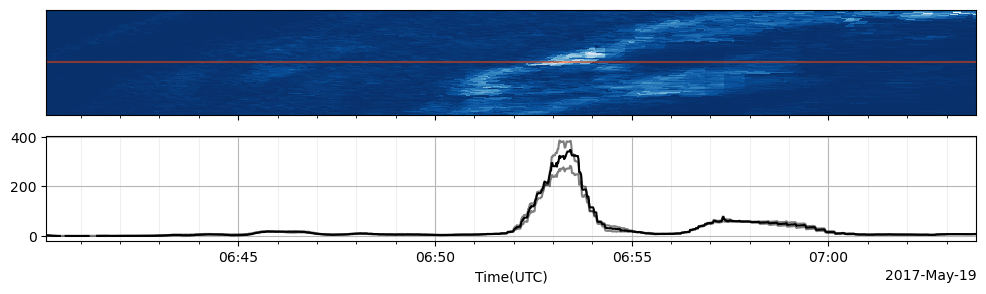

In [4]:
fig,ax = plt.subplots(2,1,figsize=(12,3),sharex=True)
ax[0].pcolormesh(uvs.datetime,
              np.arange(uvs.bri_strip.shape[0]),
              uvs.bri_strip,
              cmap="Blues_r",
              vmin=0)
ax[0].axhline(y=uvs.bri_strip.shape[0]/2,c="orangered",alpha=0.5)
ax[0].set_xlim(start_dt,end_dt)
ax[0].get_yaxis().set_visible(False)
ax[0].set_facecolor("grey")
plotting.setDateFormatter(ax[-1])
plotting.setMinorTicks(ax[-1])
plotting.setGrid(fig)
ax[-1].set_xlabel("Time(UTC)")

ax[1].plot(uvs.datetime,uvs.bri_prof[0],"k")
# ax[1].plot(uvs.datetime,uvs.bri_prof[1],"k",alpha=0.5)
ax[1].plot(uvs.datetime,uvs.bri_prof[2],"k",alpha=0.5)
# ax[1].plot(uvs.datetime,uvs.bri_prof[3],"k",alpha=0.5)
ax[1].plot(uvs.datetime,uvs.bri_prof[4],"k",alpha=0.5)

# MAG Data

fgm_jno_l3_2017139pc_pj06_r1s_v02.sts already downloaded. Use 'overwrite' if new version requested.


Text(0, 0.5, 'Current ($\\mu A/m^2$)')

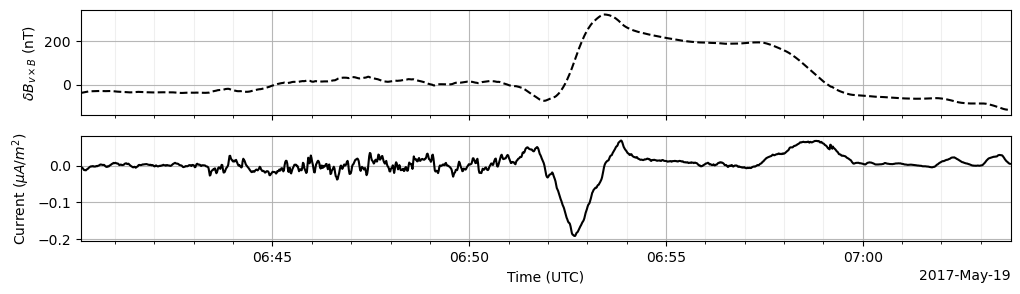

In [5]:
MAGData.downloadMAGLocal(start_dt,end_dt,overwrite=False)

mag_avg = MAGData(start_dt,end_dt,do_30s_avg=True)

fig,ax = plt.subplots(2,1,figsize=(12,3),sharex=True)
ax[0].plot(mag_avg.datetime,mag_avg.delB_vxB,c="k",ls="--")
ax[0].set_xlim(start_dt,end_dt)
plotting.setGrid(fig)
plotting.setDateFormatter(ax[-1])
plotting.setMinorTicks(ax[-1])
ax[0].set_ylabel(r"$\delta B_{v\times B}$ (nT)")
ax[-1].set_xlabel("Time (UTC)")

ax[1].plot(mag_avg.datetime,mag_avg.j_vxB,c="k")
ax[1].set_ylabel("Current ($\\mu A/m^2$)")

# JEDI Data

Text(0, 0.5, 'Normalized Mean\nEnergy Intensity\n(mW/m$^2\\cdot$sr)')

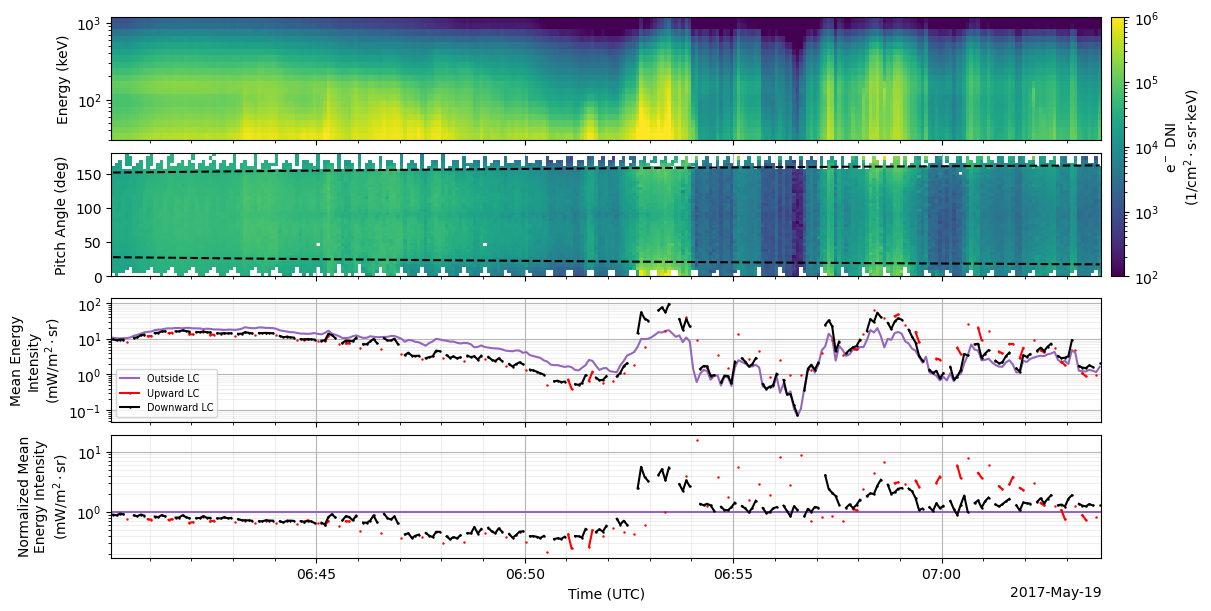

In [6]:
JEDIData.downloadJEDILocal(start_dt,end_dt)

jedi = JEDIData(start_dt,end_dt,t_res="5s")

vmin=1e2
vmax=1e6

fig,ax = plt.subplots(4,1,figsize=(12,6),sharex=True,layout="constrained")
graph = ax[0].pcolormesh(jedi.mean_times,jedi.geom_mean_energies,jedi.to_energy_dist(direction="").T,
                         norm=mcolors.LogNorm(vmin=vmin,vmax=vmax))
ax[0].set_yscale("log")
plotting.setDateFormatter(ax[0])
plotting.setMinorTicks(ax[0])
plotting.setGrid(fig)
ax[-1].set_xlabel("Time (UTC)")
ax[0].set_ylabel("Energy (keV)")

ax[1].pcolormesh(jedi.mean_times,jedi.mean_pitch_angles,jedi.to_pitch_angle_dist("DNI").T,
                 norm=mcolors.LogNorm(vmin=vmin,vmax=vmax))
ax[1].plot(jedi.mean_times,jedi.loss_cone_angle,c="k",ls="--")
ax[1].plot(jedi.mean_times,180-jedi.loss_cone_angle,c="k",ls="--")
ax[1].set_ylabel("Pitch Angle (deg)")
fig.colorbar(graph,label="e$^-$ DNI\n(1/cm$^2\\cdot$s$\\cdot$sr$\\cdot$keV)",ax=ax[0:2].ravel().tolist(),pad=0.01)

intensity = jedi.calc_mean_intensity()
ax[2].plot(jedi.mean_times,intensity["outside"],c="tab:purple",label="Outside LC")
ax[2].plot(jedi.mean_times,intensity["up"],c="r",marker=".",ms=1.5,label=f"Upward LC")
ax[2].plot(jedi.mean_times,intensity["down"],c="k",marker=".",ms=1.5,label=f"Downward LC")
ax[2].set_yscale("log")
ax[2].set_ylabel("Mean Energy\nIntensity\n(mW/m$^2\\cdot$sr)")
ax[2].legend(loc="lower left",fontsize="x-small")

ax[3].axhline(y=1,c="tab:purple",label="Outside LC")
ax[3].plot(jedi.mean_times,intensity["up"]/intensity["outside"],c="r",marker=".",ms=1.5,label=f"Upward LC")
ax[3].plot(jedi.mean_times,intensity["down"]/intensity["outside"],c="k",marker=".",ms=1.5,label=f"Downward LC")
ax[3].set_yscale("log")
ax[3].set_ylabel("Normalized Mean\nEnergy Intensity\n(mW/m$^2\\cdot$sr)")

# Example Stackplot

## Download Data

In [7]:
# UVS data must be manually downloaded from repository
MAGData.downloadMAGLocal(start_dt,end_dt)
JEDIData.downloadJEDILocal(start_dt,end_dt)
jadf.compileJADEMoments()

fgm_jno_l3_2017139pc_pj06_r1s_v02.sts already downloaded. Use 'overwrite' if new version requested.
JADE moments already downloaded. Use 'overwrite' if new version requested.


## Data for Stackplot

In [8]:
## UVS
uvs = UVSData(start_dt,end_dt)

## MAG
mag = MAGData(start_dt,end_dt,do_30s_avg=False)
mag_avg = MAGData(start_dt,end_dt,do_30s_avg=True)

## JEDI
jedi = JEDIData(start_dt,end_dt,t_res="5s")

## Density
# Waves
waves_df = utils._waves_df
waves_df = waves_df[waves_df["datetime"].between(start_dt,end_dt)]
waves_df = waves_df.sort_values(by="datetime",ignore_index=True)
# JADE
jade_df = pd.read_csv(DATA_DIR + "JADE/JADE_density_pj.dat",sep=r"\s+")
jade_df["datetime"] = pd.to_datetime(jade_df["utc"],format="%Y-%jT%H:%M:%S.%f").dt.tz_localize(None)
jade_df = jade_df[jade_df["datetime"].between(start_dt,end_dt)]
jade_df = jade_df.sort_values(by="datetime",ignore_index=True)

## Stackplot

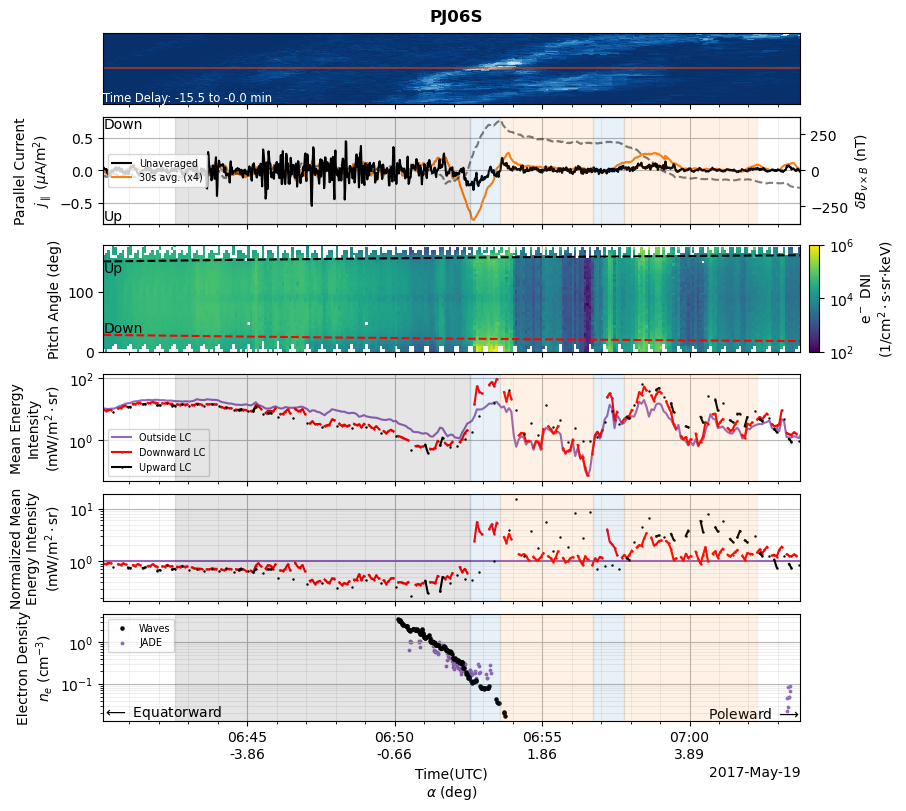

In [9]:
fig,ax = plt.subplots(6,1,figsize=(9,8),sharex=True,layout="constrained",height_ratios=[2,3,3,3,3,3])
plt.suptitle(f"PJ{event}",weight="bold")

# UVS brightness map
ax[0].pcolormesh(uvs.datetime,
              np.arange(uvs.bri_strip.shape[0]),
              uvs.bri_strip,
              cmap="Blues_r",
              vmin=0)
ax[0].axhline(y=uvs.bri_strip.shape[0]/2,c="orangered",alpha=0.5)
ax[0].get_yaxis().set_visible(False)
ax[0].set_facecolor("grey")
ax[0].set_xlim(start_dt,end_dt)
time_delay_max = np.nanmax(uvs.time_delay)
time_delay_min = np.nanmin(uvs.time_delay)
ax[0].text(0,0,f"Time Delay: {time_delay_min/60:.1f} to {time_delay_max/60:.1f} min",
           c="w",size="small",va="bottom",transform=ax[0].transAxes)
ax[-1].set_xlabel("Time(UTC)")
formatter = plotting.setDateFormatter(ax[-1])
plotting.setMinorTicks(ax[-1])
plotting.addAlphaLabel(formatter,ax[-1])
plotting.setGrid(fig)
plotting.addZoneHighlight(np.array([ax[1],ax[3],ax[4],ax[5]]))

# FAC and magnetic perturbation
ax[1].plot(mag.datetime,mag.j_vxB,c="k",label="Unaveraged")
ax[1].plot(mag_avg.datetime,4*mag_avg.j_vxB,zorder=0,c="tab:orange",label="30s avg. (x4)")
ax[1].set_ylabel("Parallel Current\n$j_\\parallel$ ($\\mu$A/m$^2$)")
ax1 = ax[1].twinx()
ax1.plot(mag.datetime,mag.delB_vxB,zorder=0,c="k",ls="--",alpha=0.5)
ax1.set_ylabel(r"$\delta B_{v\times B}$ (nT)")
#add legend for FAC
ax1.legend(*ax[1].get_legend_handles_labels(),loc="center left",fontsize="x-small")
# Align y=0 for the two plots on this panel
ax[1].set_ylim(np.max(np.abs(ax[1].get_ylim()))*np.array([-1,1]))
ax1.set_ylim(np.max(np.abs(ax1.get_ylim()))*np.array([-1,1]))
#add label for up/down
ax[1].text(0,1,jedi.para_direction.capitalize(),va="top",transform=ax[1].transAxes)
ax[1].text(0,0,jedi.anti_direction.capitalize(),va="bottom",transform=ax[1].transAxes)

# JEDI pitch angle dist.
vmin,vmax=1e2,1e6
graph = ax[2].pcolormesh(jedi.mean_times,jedi.mean_pitch_angles,jedi.to_pitch_angle_dist("DNI").T,
                         norm=mcolors.LogNorm(vmin=vmin,vmax=vmax))
ax[2].plot(jedi.mean_times,jedi.loss_cone_angle,c="r",ls="--")
ax[2].plot(jedi.mean_times,180-jedi.loss_cone_angle,c="k",ls="--")
ax[2].set_ylabel("Pitch Angle (deg)")
fig.colorbar(graph,label="e$^-$ DNI\n(1/cm$^2\\cdot$s$\\cdot$sr$\\cdot$keV)",pad=-0.09,aspect=10)
#add label for up/down
ax[2].text(0,jedi.loss_cone_angle[0],jedi.para_direction.capitalize(),c="k",va="bottom",transform=ax[2].get_yaxis_transform())
ax[2].text(0,180-jedi.loss_cone_angle[0],jedi.anti_direction.capitalize(),c="k",va="top",transform=ax[2].get_yaxis_transform())

# JEDI mean intensity
intensity = jedi.calc_mean_intensity()
ax[3].plot(jedi.mean_times,intensity["outside"],c="tab:purple",label="Outside LC")
ax[3].plot(jedi.mean_times,intensity[f"{jedi.para_direction}"],c="r",marker=".",ms=1.5,
           label=f"{jedi.para_direction.capitalize()}ward LC")
ax[3].plot(jedi.mean_times,intensity[f"{jedi.anti_direction}"],c="k",marker=".",ms=1.5,
           label=f"{jedi.anti_direction.capitalize()}ward LC")
ax[3].set_yscale("log")
ax[3].set_ylabel("Mean Energy\nIntensity\n(mW/m$^2\\cdot$sr)")
ax[3].legend(loc="lower left",fontsize="x-small")

#JEDI normalized mean intensity
ax[4].axhline(y=1,c="tab:purple",label="Outside LC")
ax[4].plot(jedi.mean_times,intensity[f"{jedi.para_direction}"]/intensity["outside"],c="r",marker=".",ms=1.5,
           label=f"{jedi.para_direction}ward LC")
ax[4].plot(jedi.mean_times,intensity[f"{jedi.anti_direction}"]/intensity["outside"],c="k",marker=".",ms=1.5,
           label=f"{jedi.anti_direction}ward LC")
ax[4].set_yscale("log")
ax[4].set_ylabel("Normalized Mean\nEnergy Intensity\n(mW/m$^2\\cdot$sr)")

# Waves and JADE density
ax[5].scatter(waves_df["datetime"],waves_df["density(cm-3)"],c="k",s=5,label="Waves")
ax[5].scatter(jade_df["datetime"],jade_df["n_cc"],c="tab:purple",s=3,label="JADE",zorder=0)
ax[5].set_yscale("log")
ax[5].set_ylabel("Electron Density\n$n_e$ (cm$^{-3}$)")
ax[5].legend(loc="upper left",fontsize="x-small")
#setting y_lim for the density plot to be at least two orders of magnitude
bot,top = ax[5].get_ylim()
if top/bot < 1e2:
    top *= 1e1
    bot /= 1e1
    ax[5].set_ylim(bot,top)